<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/colab/Intrusiones%20de%20Polvo%20Sahariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Análisis Automatizado de Intrusiones de Polvo Sahariano (2016-2024)

Este cuaderno integra datos de **CAMS** y **ERA5-Land** para identificar intrusiones de polvo sahariano.
El modelo utiliza un **Índice Sintético de Calima** (Score 0-3) basado en tres pilares físicos:
1. **Masa de partículas (PM10):** Umbral superior a 60 µg/m³.
2. **Higrometría (Humedad):** Condiciones de aridez (umbral corregido por zona).
3. **Atenuación Radiativa (UV):** Bloqueo de radiación solar por aerosoles.
4. **Filtro de Procedencia (Dirección del Viento):** Filtrado dinámico de trayectorias (Sector S/SE), garantizando que las masas de aire analizadas tengan un origen geográfico compatible con la cuenca del Sahara.

In [1]:
#@title 🔧 Configuración del Entorno y Carga de Datos { display-mode: "form" }
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Montaje de Drive y definición de rutas
if not os.path.isdir('/content/drive'):
    drive.mount('/content/drive')

PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Resultados_TFM_Final")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# Carga del Dataset consolidado
df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df['anio'] = df['time'].dt.year

# Filtro temporal (2016 - 2024)
df = df[(df['anio'] >= 2016) & (df['anio'] <= 2024)].copy()

print(f"✅ Datos cargados correctamente. Registros: {len(df)}")

Mounted at /content/drive
✅ Datos cargados correctamente. Registros: 394560


### 2. Metodología: Índice Sintético de Intrusión (ISI)
Definimos un **Episodio de Intrusión Sahariana** cuando el sistema detecta una convergencia física y geográfica.

* **Criterio de clasificación:** Se considera episodio confirmado si el **score combinado alcanza al menos 3 de los 4 indicadores físicos** (PM10, Humedad ajustada, Atenuación UV y Procedencia del flujo).
* **Nota técnica:** Se han aplicado **umbrales de humedad diferenciados** (Costa vs. Interior) para evitar sesgos provocados por la higrometría marítima, y un **filtro de procedencia (Sector S/SE)** para garantizar que la masa de aire tenga un origen geográfico compatible con el desierto del Sahara.

In [2]:
#@title 🧮 Cálculo del Índice Sintético de Intrusión Sahariana { display-mode: "form" }

# Aseguramos existencia de Zona
if 'Zona' not in df.columns:
    costeras = ['Cartagena', 'San Javier', 'Mazarrón', 'Águilas', 'Torre-Pacheco']
    df['Zona'] = df['Estacion'].apply(lambda x: 'Costa' if x in costeras else 'Interior')

def calcular_indice_sahariano(row):
    # 1. PM10: Masa de partículas
    pm10 = 1 if row['PM10'] > 60 else 0

    # 2. Humedad: Aire continental seco
    h_lim = 60 if row['Zona'] == 'Costa' else 40
    hum = 1 if row['Hum'] < h_lim else 0

    # 3. Atenuación UV: Bloqueo de radiación
    uv = 1 if (row['UV_Cielo_Despejado'] - row['UV_Real']) > 1.5 else 0

    # 4. Viento: Procedencia del sector Sur/Sureste (Sahara)
    # Entre 135 y 225 grados
    viento = 1 if 135 <= row['Viento_Dir'] <= 225 else 0

    # Retornamos la suma de todos los parámetros
    return pm10 + hum + uv + viento

# Calculamos el Score (de 0 a 4 puntos)
# Exigimos al menos 3 puntos para ser considerados evento sahariano (Rigor científico)
df['score_sahariano'] = df.apply(calcular_indice_sahariano, axis=1)
df['es_episodio_sahariano'] = df['score_sahariano'] >= 3

# Agrupación estadística
resumen_anual = df[df['es_episodio_sahariano'] == True].groupby(['anio', 'Estacion', 'Zona']).size().reset_index(name='Eventos_3H')
resumen_anual['Horas_Intrusion'] = resumen_anual['Eventos_3H'] * 3

# Exportar tabla maestra
resumen_anual.to_csv(os.path.join(RUTA_OUTPUT, "Tabla_Maestra_Intrusiones_Saharianas.csv"), index=False)
print("✅ Cálculo completado: Índice de 4 pilares (PM10, Hum, UV, Viento).")
print("✅ Tabla maestra guardada en: Tabla_Maestra_Intrusiones_Saharianas.csv")

✅ Cálculo completado: Índice de 4 pilares (PM10, Hum, UV, Viento).
✅ Tabla maestra guardada en: Tabla_Maestra_Intrusiones_Saharianas.csv


### 3. Análisis Espacial y Temporal: Intrusiones Saharianas
Presentamos la comparación geográfica para evaluar la persistencia de las intrusiones según la localización, seguido de una matriz de calor anual que destaca los años anómalos (especialmente los eventos de 2021-2022). Este análisis permite cuantificar la frecuencia e intensidad de los episodios de polvo mineral, discriminando el comportamiento diferencial entre las estaciones de costa e interior.

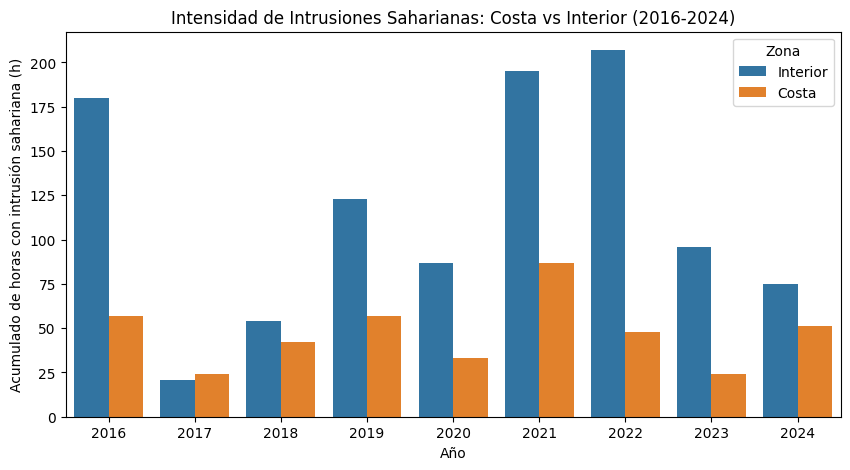

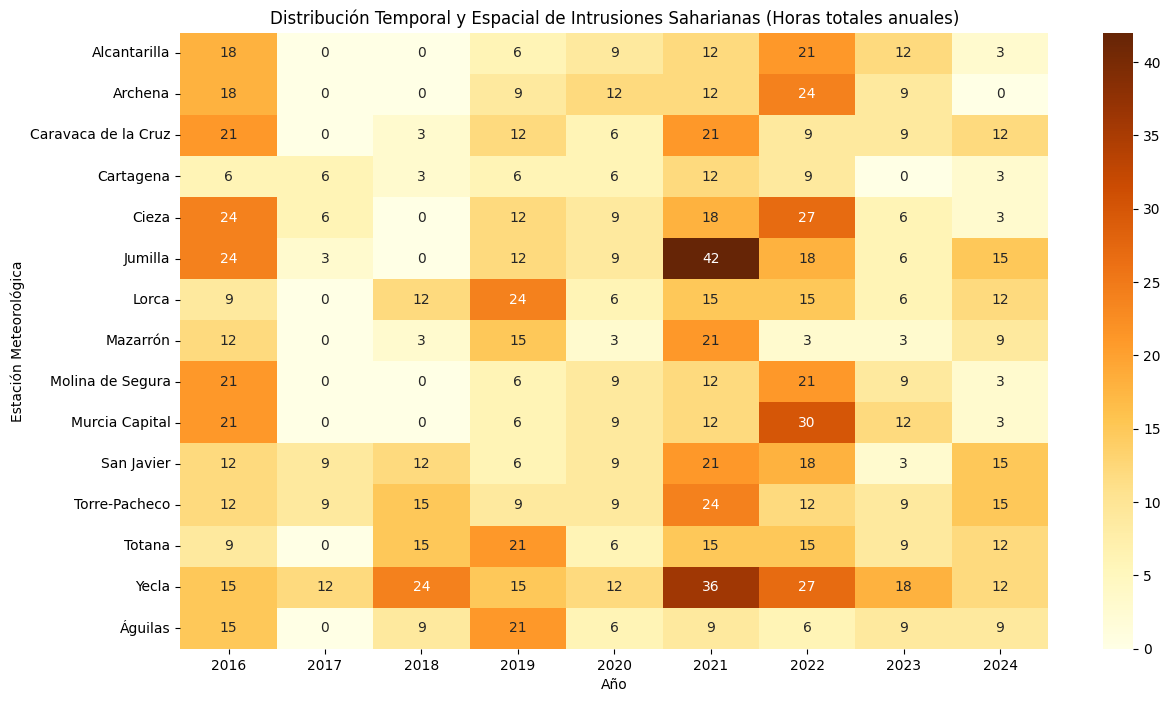

✅ Gráficas generadas y guardadas en: /content/drive/MyDrive/TFM_Profesorado/Resultados_TFM_Final


In [3]:
#@title 📊 Visualización de Resultados para el TFM { display-mode: "form" }

# Aseguramos que usamos los nombres de columnas actualizados
col_nombre = 'Horas_Intrusion'
col_eje_y = 'Acumulado de horas con intrusión sahariana (h)'

# Figura 1: Comparativa
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='anio', y=col_nombre, hue='Zona', data=resumen_anual, estimator=sum, errorbar=None)
ax.set(xlabel='Año', ylabel=col_eje_y)
plt.title("Intensidad de Intrusiones Saharianas: Costa vs Interior (2016-2024)")
plt.savefig(os.path.join(RUTA_OUTPUT, "Figura_1_Polvo_Sahariano_Zonas.png"), dpi=300)
plt.show()

# Figura 2: Heatmap
df_pivot = resumen_anual.pivot(index='Estacion', columns='anio', values=col_nombre).fillna(0)
plt.figure(figsize=(14, 8))
bx = sns.heatmap(df_pivot, annot=True, cmap="YlOrBr", fmt=".0f")
bx.set(xlabel='Año', ylabel='Estación Meteorológica')
plt.title("Distribución Temporal y Espacial de Intrusiones Saharianas (Horas totales anuales)")
plt.savefig(os.path.join(RUTA_OUTPUT, "Figura_2_Heatmap_Polvo.png"), dpi=300)
plt.show()

print(f"✅ Gráficas generadas y guardadas en: {RUTA_OUTPUT}")